# 7.4  모폴로지
형태학이라는 뜻으로 영상의 객체들의 형태를 분석하고 처리하는 기법이다. 영상 내에 존재하는 객체의 형태를 변형시켜서 불필요한 잡음을 제거하거나 객체를 뚜렷하게 하여 영상의 경계, 골격, 블록 등의 형태를 표현하는데 필요한 요소를 추출한다.  
모폴로지는 이진 영상에서 수행되고 대표적인 연산 방법으로 침식 연산과 팽창 연산이 있으며 둘을 조합한 닫힘, 열림 연산이 있다.  

## 7.4.1 침식 연산
침식을 시켜 객체의 크기는 축소되고 배경은 확장시키는 연산이며 크기 축소로 인해서 잡음 같은 작은 크기의 객체들은 사라질 수 있다.  
이러한 현상을 이용해서 소금-후추 잡음, 임펄스 잡음들을 제거하고 영상 내에서 객체의 돌출부를 감소시켜서 서로 닿는 물체를 분리할 때도 유용하다.  
마스크와 모두 같아야 침식 시키지 않는다.

In [1]:
import numpy as np, cv2
import matplotlib.pyplot as plt

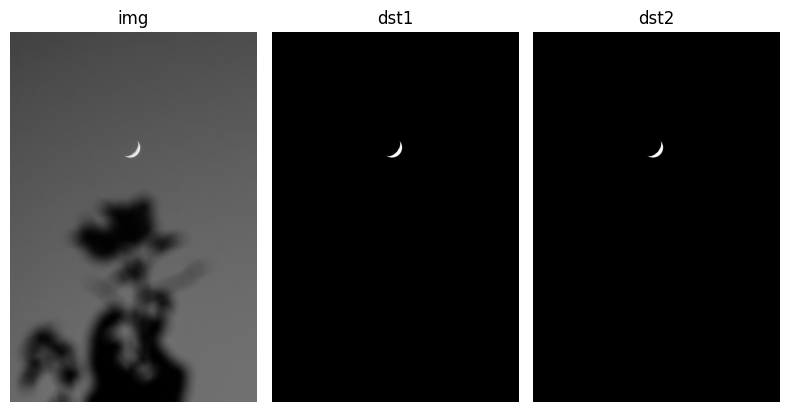

In [ ]:
def erode(img, mask=None):
    dst = np.zeros(img.shape, np.uint8)
    if mask is None: mask = np.ones((3, 3), np.uint8)
    ycenter, xcenter = np.divmod(mask.shape[:2], 2)[0]

    mcnt = cv2.countNonZero(mask) # 일치하는 원소의 개수를 파악하는 함수
    for i in range(ycenter, img.shape[0] - ycenter):
        for j in range(xcenter, img.shape[1] - xcenter):
            y1, y2 = i - ycenter, i + ycenter + 1
            x1, x2 = j - xcenter, j + xcenter + 1
            roi = img[y1:y2, x1:x2]
            temp = cv2.bitwise_and(roi, mask)
            cnt = cv2.countNonZero(temp)
            dst[i, j] = 255 if (cnt == mcnt) else 0
        
    return dst

img = cv2.imread("../images/moon.jpg", cv2.IMREAD_GRAYSCALE)

data = [
    0, 1, 0,
    1, 1, 1,
    0, 1, 0
]
mask = np.array(data, np.uint8).reshape(3, 3)
th_img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)[1]

dst1 = erode(th_img, mask)
dst2 = cv2.erode(th_img, mask)

titles = ['img', 'dst1', 'dst2']
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 20))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7.4.2 팽창 연산
팽창은 객체의 가장 외곽 화소를 확장시키기 때문에 객체의 크기는 확대되고 배경은 축소된다. 또한 객체 내부의 빈 공간도 메워지게 된다.

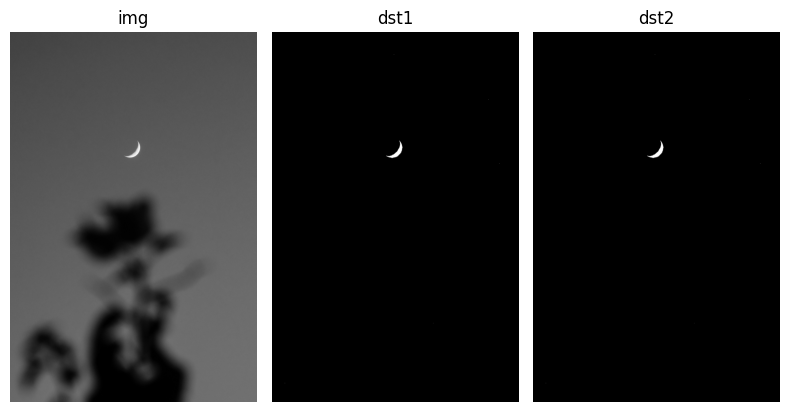

In [5]:
def dilate(img, mask=None):
    dst = np.zeros(img.shape, np.uint8)
    if mask is None: mask = np.ones((3, 3), np.uint8)
    ycenter, xcenter = np.divmod(mask.shape[:2], 2)[0]

    for i in range(ycenter, img.shape[0] - ycenter):
        for j in range(xcenter, img.shape[1] - xcenter):
            y1, y2 = i - ycenter, i + ycenter + 1
            x1, x2 = j - xcenter, j + xcenter + 1
            roi = img[y1:y2, x1:x2]
            temp = cv2.bitwise_and(roi, mask)
            cnt = cv2.countNonZero(temp)
            dst[i, j] = 0 if (cnt == 0) else 255
        
    return dst

img = cv2.imread("../images/moon.jpg", cv2.IMREAD_GRAYSCALE)

data = [
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
]
mask = np.array(data).astype('uint8')
th_img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)[1]

dst1 = dilate(th_img, mask)
dst2 = cv2.dilate(th_img, mask)

titles = ['img', 'dst1', 'dst2']
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 20))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7.4.3 열림 연산과 닫침연산
* 열림 연산  
침식 연산을 먼저 수행하고 바로 팽창 연산을 수행한다. 그래서 침식으로 인해 객체는 축소되고 배경 부분의 미세한 잡음들은 제거되고 축소된 객체를 팽창으로 다시 원래 크기로 돌아온다.  

* 닫힘 연산  
열림 연산의 반대로 수행되고 팽창연산으로 객체가 확장되어 객체의 빈공간이 채워지고 침식 연산으로 확장된 객체의 크기가 원래대로 축소된다.
  
그리고 연산의 결과가 미흡하다면 반복적으로 수행이 가능하다.

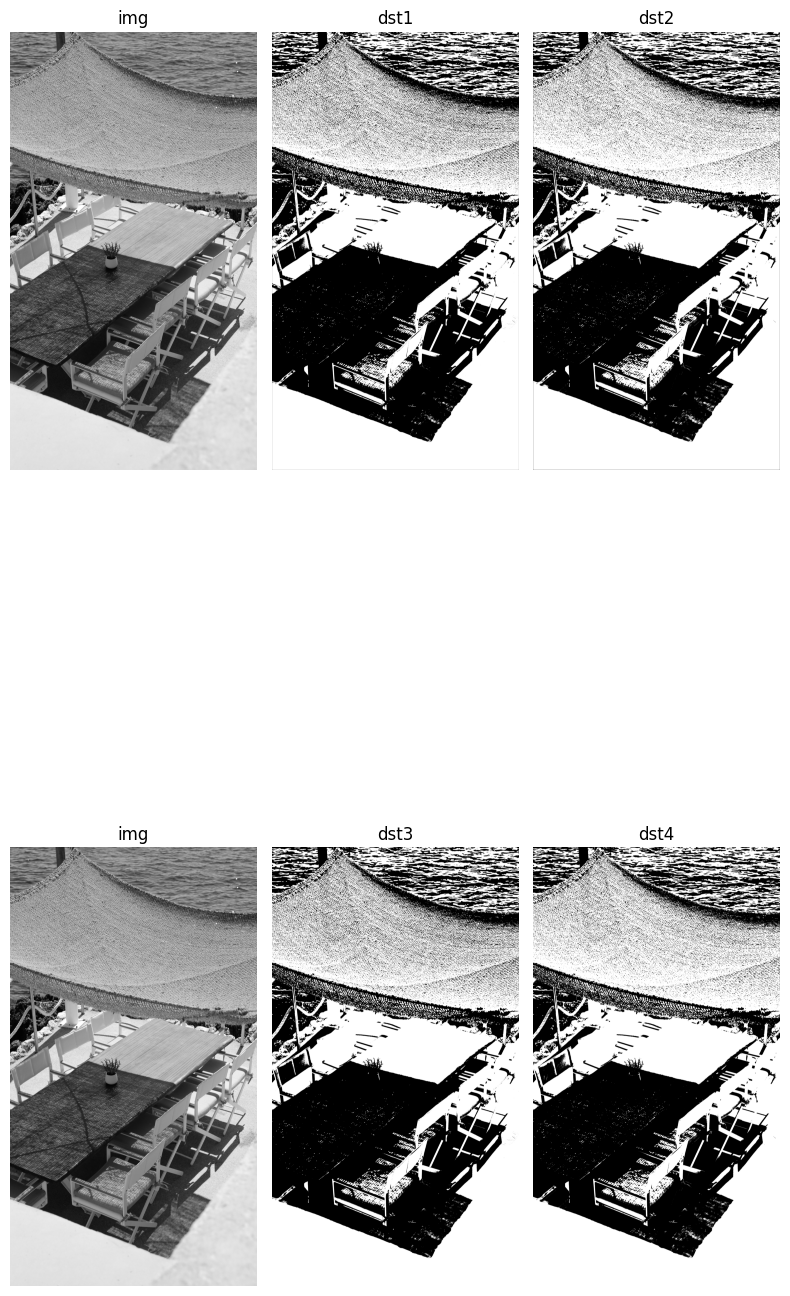

In [6]:
def opening(img, mask):
    tmp = erode(img, mask)
    dst = dilate(tmp, mask)
    return dst

def closing(img, mask):
    tmp = dilate(img, mask)
    dst = erode(tmp, mask)
    return dst

img = cv2.imread("../images/bench.jpg", cv2.IMREAD_GRAYSCALE)

data = [
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
]
mask = np.array(data).astype('uint8')
th_img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)[1]

dst1 = opening(th_img, mask)
dst2 = closing(th_img, mask)
dst3 = cv2.morphologyEx(th_img, cv2.MORPH_OPEN, mask)
dst4 = cv2.morphologyEx(th_img, cv2.MORPH_CLOSE, mask, iterations = 1)

titles = ['img', 'dst1', 'dst2', 'img', 'dst3', 'dst4']
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8, 20))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()